In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split

We will keep adding libraries in libraries as we need them 
Now loading and cleaning the data is upto us 


In [2]:
df = pd.read_csv("patients.csv")

In [3]:

print(df.sample(10))
print(f"Data types:\n{df.dtypes}\n")

print(f"Information about DataFram: {df.info()}\n")

print(df.shape)

     Patient_ID  Age  Gender   BMI  Systolic_BP  Diastolic_BP  Cholesterol  \
41           42   27  Female  21.8          108            68          150   
275         276   34  Female  23.4          116            74          170   
277         278   49  Female  27.2          132            84          210   
27           28   51  Female  27.6          134            84          212   
117         118   50  Female  27.0          132            84          208   
299         300   64  Female  31.8          156            94          248   
257         258   47  Female  27.0          132            84          204   
72           73   71    Male  34.0          168           100          256   
225         226   35  Female  23.4          116            74          170   
28           29   37    Male  25.0          122            78          182   

    Glucose Smoker Family_History  Exercise_Hours_Per_Week  Heart_Disease  
41       82     No             No                        8       

Glucose Should Have been a number


In [4]:
print(f"Missing values:\n{df.isnull().sum()}\n")

Missing values:
Patient_ID                 0
Age                        0
Gender                     0
BMI                        0
Systolic_BP                0
Diastolic_BP               0
Cholesterol                0
Glucose                    0
Smoker                     0
Family_History             0
Exercise_Hours_Per_Week    0
Heart_Disease              0
dtype: int64



In [5]:
df.describe(include='all')

,Patient_ID,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Cholesterol,Glucose,Smoker,Family_History,Exercise_Hours_Per_Week,Heart_Disease
count,320.000000,320.000000,320,320.000000,320.000000,320.000000,320.000000,320,320,320,320.000000,320.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,52,2,2,NaN,NaN
top,NaN,NaN,Male,NaN,NaN,NaN,NaN,90,No,No,NaN,NaN
freq,NaN,NaN,161,NaN,NaN,NaN,NaN,26,192,165,NaN,NaN
mean,160.500000,51.162500,NaN,28.190313,138.618750,85.609375,213.546875,NaN,NaN,NaN,3.428125,0.403125
std,92.520268,13.863819,NaN,3.919887,19.938423,10.114109,34.830413,NaN,NaN,NaN,2.435595,0.491294
min,1.000000,26.000000,NaN,21.400000,108.000000,68.000000,148.000000,NaN,NaN,NaN,0.000000,0.000000
25%,80.750000,39.000000,NaN,24.600000,120.000000,76.000000,181.500000,NaN,NaN,NaN,1.000000,0.000000
50%,160.500000,51.000000,NaN,28.050000,136.500000,85.500000,215.000000,NaN,NaN,NaN,3.000000,0.000000
75%,240.250000,64.000000,NaN,31.800000,156.000000,94.000000,248.000000,NaN,NaN,NaN,5.000000,1.000000


No mathematical Computation result is shown for glucose meaning its somewhat problem data. lets try value_counts 

In [6]:
df['Heart_Disease'].value_counts()

Heart_Disease
0    191
1    129
Name: count, dtype: int64

In [7]:
df['Glucose'].value_counts()

Glucose
90             26
88             23
102            15
96             15
92             14
98             14
128            12
158            12
94             11
84             10
104            10
118            10
168            10
170             9
172             9
132             9
130             8
82              7
162             7
160             6
150             6
148             6
116             6
86              5
178             5
122             5
180             4
124             4
182             4
156             4
100             3
120             3
154             3
80              3
165             2
152             2
176             2
114             2
110             1
140             1
85              1
105             1
145             1
125             1
135             1
95              1
108             1
112             1
138             1
155             1
17 baseline     1
146             1
Name: count, dtype: int64

17 baseline is too low but it must be a typo error or something like that, its outlier like this 


In [8]:
print(df['Gender'].value_counts())

print(df['Smoker'].value_counts())

print(df['Family_History'].value_counts())

Gender
Male      161
Female    159
Name: count, dtype: int64
Smoker
No     192
Yes    128
Name: count, dtype: int64
Family_History
No     165
Yes    155
Name: count, dtype: int64


In [9]:
df['Glucose']= df['Glucose'].astype('str').str.replace(r'\s*baseline\s*','',regex=True)
df['Glucose']= pd.to_numeric(df['Glucose'],errors='coerce')

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Smoker']= df['Smoker'].map({"No": 0,"Yes": 1})
# df['Smoker']= pd.to_numeric(df['Smoker'],errors='coerce')
# df['Family_History'] = df['Family_History'].map({"Yes": 1,"No": 0})
# df['Family_History'] = pd.to_numeric(df["Family_History"],errors='coerce')
df['Family_History'] = df['Family_History'].astype('category').cat.codes #another method to convert categorical data to numerical data

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               320 non-null    int64  
 1   Age                      320 non-null    int64  
 2   Gender                   320 non-null    int64  
 3   BMI                      320 non-null    float64
 4   Systolic_BP              320 non-null    int64  
 5   Diastolic_BP             320 non-null    int64  
 6   Cholesterol              320 non-null    int64  
 7   Glucose                  320 non-null    int64  
 8   Smoker                   320 non-null    int64  
 9   Family_History           320 non-null    int8   
 10  Exercise_Hours_Per_Week  320 non-null    int64  
 11  Heart_Disease            320 non-null    int64  
dtypes: float64(1), int64(10), int8(1)
memory usage: 27.9 KB


We dont need Patient ID in our Model because thats only good for diagnosis and other Related Activities but in Model Training thats no use ,lets drop it.

In [10]:
try:
    df = df.drop(columns= ['Patient_ID'])
    df = df.dropna()
except KeyError:
    print("Column 'Patient_ID' does not exist in the DataFrame.")
    print("Proceeding without dropping the column.")
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      320 non-null    int64  
 1   Gender                   320 non-null    int64  
 2   BMI                      320 non-null    float64
 3   Systolic_BP              320 non-null    int64  
 4   Diastolic_BP             320 non-null    int64  
 5   Cholesterol              320 non-null    int64  
 6   Glucose                  320 non-null    int64  
 7   Smoker                   320 non-null    int64  
 8   Family_History           320 non-null    int8   
 9   Exercise_Hours_Per_Week  320 non-null    int64  
 10  Heart_Disease            320 non-null    int64  
dtypes: float64(1), int64(9), int8(1)
memory usage: 25.4 KB
None
              Age      Gender         BMI  Systolic_BP  Diastolic_BP  \
count  320.000000  320.000000  320.000000   320.000000    320.00000

In [11]:
# print(f"Missing Records : {df['Glucose'].isnull().sum()}")
# df['Glucose']= df['Glucose'].fillna(df['Glucose'].median())
# print(f"Missing Records : {df['Glucose'].isnull().sum()}")

In [13]:
X = df.drop(columns=['Heart_Disease'])
X

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Cholesterol,Glucose,Smoker,Family_History,Exercise_Hours_Per_Week
0,45,1,24.5,118,76,180,92,0,0,5
1,62,0,29.3,142,88,225,110,1,1,2
2,55,1,31.2,156,96,245,140,1,0,1
3,38,0,22.1,110,72,165,88,0,0,6
4,70,1,33.7,168,98,260,160,1,1,0
...,...,...,...,...,...,...,...,...,...,...
315,36,0,23.6,118,74,176,90,0,0,6
316,69,1,33.2,166,98,258,168,1,1,1
317,49,0,27.2,132,84,210,104,0,1,3
318,34,1,24.0,118,74,174,90,0,0,7


In [14]:
y = df['Heart_Disease']
y

0      0
1      1
2      1
3      0
4      1
      ..
315    0
316    1
317    0
318    0
319    1
Name: Heart_Disease, Length: 320, dtype: int64

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.34,random_state=42)
X_train


,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Cholesterol,Glucose,Smoker,Family_History,Exercise_Hours_Per_Week
182,74,1,34.8,174,104,266,180,1,1,0
92,70,1,33.8,170,100,260,172,1,1,0
79,69,0,33.0,166,98,258,165,1,1,0
220,51,1,28.2,138,86,218,114,0,0,4
152,67,1,33.0,162,98,252,162,1,1,1
...,...,...,...,...,...,...,...,...,...,...
188,33,1,23.6,116,74,168,88,0,0,7
71,28,0,21.6,108,68,150,82,0,0,8
106,67,1,32.8,162,98,252,160,1,1,1
270,55,1,28.8,142,88,224,122,0,1,3


In [16]:
X_test

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Cholesterol,Glucose,Smoker,Family_History,Exercise_Hours_Per_Week
167,46,0,26.6,128,82,200,98,0,1,3
230,55,1,28.8,142,88,224,122,0,1,3
25,39,0,23.9,118,74,172,90,0,0,6
63,44,0,26.2,126,80,196,96,0,0,5
9,58,1,30.1,148,90,235,125,1,0,2
...,...,...,...,...,...,...,...,...,...,...
197,49,0,27.2,132,84,210,104,0,1,3
18,56,0,30.5,148,92,238,128,1,0,2
184,61,1,30.6,150,92,238,132,1,1,2
113,44,0,26.4,128,80,200,98,0,0,5


As you can see some of our data is extremely big and some are just true and false so they became after cleaning at 0 and 1s so we have some very overpowering features. 
we have to set them on a scale so nothing becomes overpowered 
we will use a standard scaler for that 


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #Rule of Thumb Always fit_transform on Training and transform on testing data
X_test_scaled = scaler.transform(X_test)


In [18]:
X_train_scaled

array([[ 1.64491197,  1.04360381,  1.68185504, ...,  1.25426103,
         1.06363205, -1.41744946],
       [ 1.35801267,  1.04360381,  1.42861061, ...,  1.25426103,
         1.06363205, -1.41744946],
       [ 1.28628785, -0.95821804,  1.22601507, ...,  1.25426103,
         1.06363205, -1.41744946],
       ...,
       [ 1.1428382 ,  1.04360381,  1.17536619, ...,  1.25426103,
         1.06363205, -1.00830878],
       [ 0.2821403 ,  1.04360381,  0.16238849, ..., -0.79728221,
         1.06363205, -0.19002742],
       [ 1.64491197,  1.04360381,  1.68185504, ...,  1.25426103,
         1.06363205, -1.41744946]], shape=(211, 10))

In [26]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0).fit(X_train_scaled,y_train)
print(model.predict(X_train_scaled))
print(f"Training Accuracy: {model.score(X_train_scaled,y_train):.2%}")

[1 1 1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 1 1 1 0 0 0 1 0 1 1 1 0
 0 0 0 1 0 0 1 0 0 0 1 1 1 1 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1
 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 1
 1 1 1 0 1 0 0 1 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 1 0 1 0 0 0
 1 0 1 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 1 1 1 0 0 1 0 1 1 0
 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 1 0 1 1 0 0 1 0 1]
Training Accuracy: 100.00%


In [25]:
print(model.predict(X_test_scaled))
print(f"Testing Accuracy: {model.score(X_test_scaled,y_test):.2%}")


[0 0 0 0 1 0 1 0 1 1 0 1 1 0 1 1 1 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1
 1 1 1 1 0 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 0 1 1 0 0 1 0 1 0 1 1 1 1 0 1 1 0
 0 0 1 0 1 0 0 0 1 1 0 1 0 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 1 1 0 1 1 0 0]
Testing Accuracy: 99.08%


In [28]:
model1 = LogisticRegression(random_state=0,
C=1,
fit_intercept=True,
).fit(X_train_scaled,y_train)

In [43]:
y_pred = model1.predict(X_test_scaled)
print(y_pred)
print(f"Model Training Data Accuracy: {model1.score(X_train_scaled,y_train):.2%}")

[0 0 0 0 1 0 1 0 1 1 0 1 1 0 1 1 1 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1
 1 1 1 1 0 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 0 1 1 0 0 1 0 1 0 1 1 1 1 0 1 1 0
 0 0 1 0 1 0 0 0 1 1 0 1 0 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 1 1 0 1 1 0 0]
Model Training Data Accuracy: 100.00%


In [30]:
print(f"model1 Testing Accuracy: {model1.score(X_test_scaled,y_test):.2%}")

model1 Testing Accuracy: 99.08%


In [44]:
modeln=LogisticRegression(random_state=9,C=1,fit_intercept=True).fit(X_train,y_train)
yn_pred = modeln.predict(X_test)
print(f"Modeln Training Accuracy: {modeln.score(X_train,y_train):.2%}",f"Modeln Testing Accuracy: {modeln.score(X_test,y_test):.2%}")
print(f"Model Training Accuracy: {model1.score(X_train_scaled,y_train):.2%}",f"Model Testing Accuracy: {model1.score(X_test_scaled,y_test):.2%}")

Modeln Training Accuracy: 100.00% Modeln Testing Accuracy: 99.08%
Model Training Accuracy: 100.00% Model Testing Accuracy: 99.08%


/Users/macbookair/Desktop/ML/VE/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/macbookair/Desktop/ML/VE/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/var/folders/ks/sp26_25d5qx2pl5vw8yx56km0000gn/T/ipykernel_27073/3755462197.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importance.values, y=top_importance.index, palette='vlag', ax=axes[2])


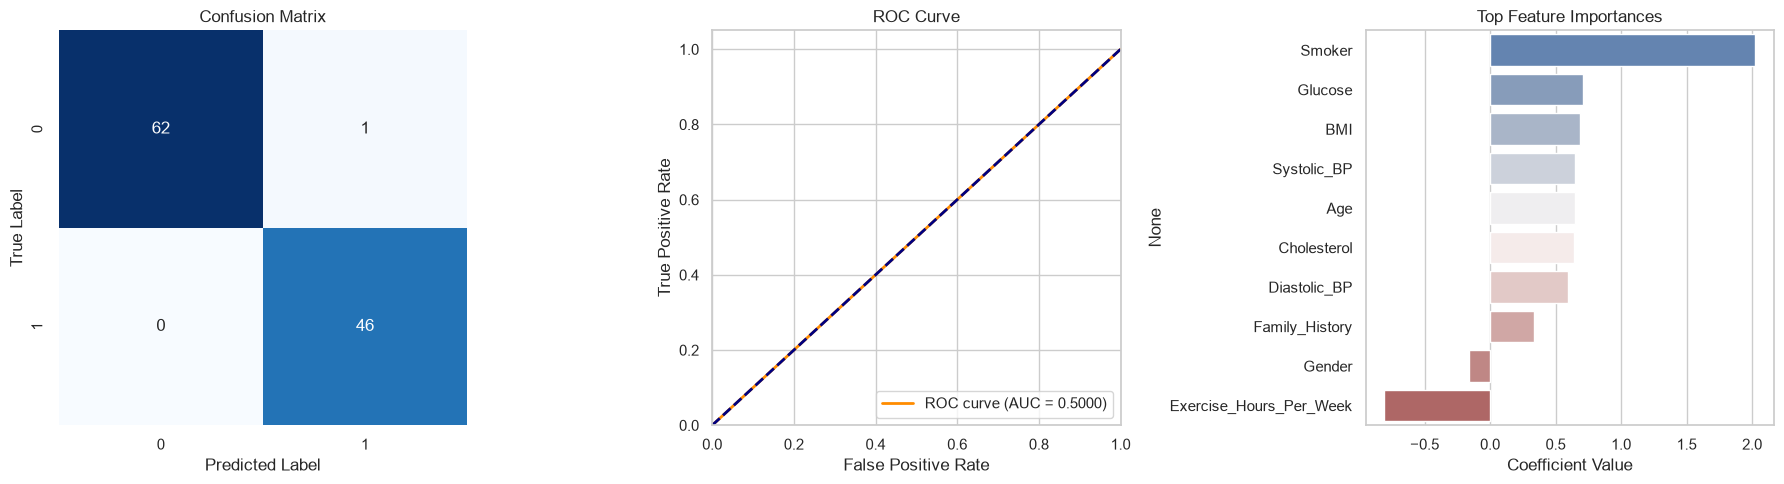

In [48]:

from sklearn.metrics import confusion_matrix, roc_curve, auc

# Set seaborn style for clean visuals
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------------------------------------------
# 1. Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ---------------------------------------------------------
# 2. ROC Curve (Receiver Operating Characteristic)
# ---------------------------------------------------------
# Requires probability estimates: 
y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

# ---------------------------------------------------------
# 3. Feature Importance (For Logistic Regression / Trees)
# ---------------------------------------------------------
# For Logistic Regression: coefficients
import pandas as pd
importance = pd.Series(model.coef_[0], index=X_train.columns).sort_values(ascending=False)

# Take top 10 most influential features
top_importance = importance.head(10)
sns.barplot(x=top_importance.values, y=top_importance.index, palette='vlag', ax=axes[2])
axes[2].set_title('Top Feature Importances')
axes[2].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

In [47]:
pd.Series(y_test).value_counts()

Heart_Disease
0    63
1    46
Name: count, dtype: int64

In [49]:
roc_auc

0.5

In [50]:
# Check correlation of all features with Heart_Disease
df.corr()['Heart_Disease'].sort_values(ascending=False)

Heart_Disease              1.000000
Smoker                     0.980515
Systolic_BP                0.874353
BMI                        0.866383
Glucose                    0.865919
Age                        0.856065
Diastolic_BP               0.853184
Cholesterol                0.849367
Family_History             0.758685
Gender                     0.370743
Exercise_Hours_Per_Week   -0.857262
Name: Heart_Disease, dtype: float64

In [51]:
# Example: Drop high-leverage clinical measurements to make classification harder
X_harder = df.drop(columns=['Heart_Disease', 'Systolic_BP', 'Diastolic_BP', 'Glucose'])

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_harder, y, test_size=0.34, random_state=42
)

scaler_h = StandardScaler()
X_train_scaled_h = scaler_h.fit_transform(X_train_h)
X_test_scaled_h = scaler_h.transform(X_test_h)

model_harder = LogisticRegression(random_state=0).fit(X_train_scaled_h, y_train_h)

print(f"Training Accuracy: {model_harder.score(X_train_scaled_h, y_train_h):.2%}")
print(f"Testing Accuracy: {model_harder.score(X_test_scaled_h, y_test_h):.2%}")

Training Accuracy: 100.00%
Testing Accuracy: 99.08%


In [52]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print(f"5-Fold CV Accuracy: {scores.mean():.2%} (+/- {scores.std():.2%})")

5-Fold CV Accuracy: 100.00% (+/- 0.00%)


In [53]:
# Step 1: Identify Leakage Candidates
# Print features with absolute correlation > 0.8 with the target
correlations = df.corr()['Heart_Disease'].abs().sort_values(ascending=False)
print("Top Target Correlations:")
print(correlations[correlations > 0.8])

Top Target Correlations:
Heart_Disease              1.000000
Smoker                     0.980515
Systolic_BP                0.874353
BMI                        0.866383
Glucose                    0.865919
Exercise_Hours_Per_Week    0.857262
Age                        0.856065
Diastolic_BP               0.853184
Cholesterol                0.849367
Name: Heart_Disease, dtype: float64


In [54]:
# Step 2: Test Single-Feature Predictability
# If a single feature achieves near 100% accuracy, it is a target leak
from sklearn.metrics import accuracy_score

for col in X.columns:
    acc = accuracy_score(y, X[col] > X[col].median())
    if acc > 0.85:
        print(f"Feature '{col}' alone yields {acc:.2%} accuracy (Potential Leak)")

Feature 'Age' alone yields 90.94% accuracy (Potential Leak)
Feature 'BMI' alone yields 90.31% accuracy (Potential Leak)
Feature 'Systolic_BP' alone yields 90.31% accuracy (Potential Leak)
Feature 'Diastolic_BP' alone yields 90.31% accuracy (Potential Leak)
Feature 'Cholesterol' alone yields 90.31% accuracy (Potential Leak)
Feature 'Glucose' alone yields 89.69% accuracy (Potential Leak)
Feature 'Smoker' alone yields 99.06% accuracy (Potential Leak)
Feature 'Family_History' alone yields 87.50% accuracy (Potential Leak)


In [55]:
# Step 3: Train Model Without Suspect Features
# Drop suspected leak columns and re-evaluate
leak_cols = ['Heart_Disease'] # Add identified leak columns here
X_clean = df.drop(columns=leak_cols)

X_tr, X_te, y_tr, y_te = train_test_split(X_clean, y, test_size=0.34, random_state=42)
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

clean_model = LogisticRegression().fit(X_tr_scaled, y_tr)
print(f"Clean Test Accuracy: {clean_model.score(X_te_scaled, y_te):.2%}")

Clean Test Accuracy: 99.08%
